<div class="markdown-google-sans">
  <h1>Introduction to feed-forward neural networks</h2>
</div>





# scikit-learn


`scikit-learn` is an open source machine learning library that supports supervised and unsupervised learning. It also provides various tools for model fitting, data preprocessing, model selection, model evaluation, and many other utilities.

### Loading the data



In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.metrics import mean_squared_error, mean_absolute_error

GLOBAL_RANDOM_STATE = 21


In [ ]:
data, target = fetch_california_housing(return_X_y=True, as_frame=True)

<Axes: xlabel='Latitude', ylabel='Longitude'>

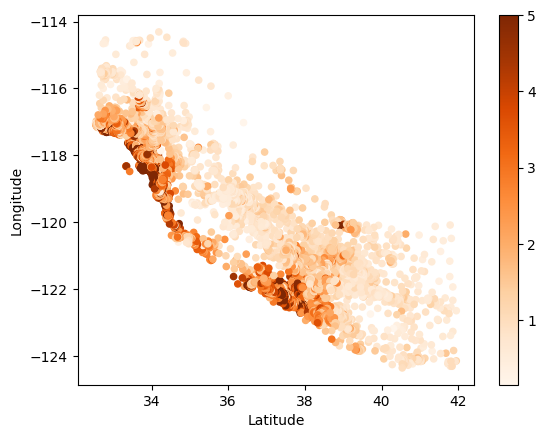

In [ ]:
data.plot.scatter(x='Latitude', y='Longitude', c=target, cmap='Oranges')

In [ ]:
data.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(data, target, test_size=.2, random_state=GLOBAL_RANDOM_STATE, shuffle=True)

In [ ]:
ScalerX = StandardScaler()
X_train_stand = ScalerX.fit_transform(X_train)
X_test_stand = ScalerX.transform(X_test)

### Constructing the model


In [ ]:
from sklearn.neural_network import MLPRegressor
#https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html

In [ ]:
sklearn_model = MLPRegressor(hidden_layer_sizes=[2**10, 2**7, 2**5], max_iter=5, batch_size=200, validation_fraction=.1, early_stopping=True, verbose=True)
sklearn_model.fit(X_train, Y_train)

Iteration 1, loss = 254.85666404
Validation score: -1.026000
Iteration 2, loss = 0.70952982
Validation score: 0.083138
Iteration 3, loss = 0.58302122
Validation score: -0.258903
Iteration 4, loss = 0.63663121
Validation score: 0.359719
Iteration 5, loss = 0.44173383
Validation score: 0.416922


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(batch_size=200, early_stopping=True,
             hidden_layer_sizes=[1024, 128, 32], max_iter=5, verbose=True)

In [ ]:
#@title TASK 1: implement the same model for the standardized data, experimenting with higher/lower batch sizes
sklearn_model_stand = MLPRegressor(hidden_layer_sizes=[2**10, 2**7, 2**5], max_iter=3, early_stopping=True, verbose=True)
sklearn_model_stand.fit(X_train_stand, Y_train)

Iteration 1, loss = 0.47084885
Validation score: 0.629427
Iteration 2, loss = 0.20278878
Validation score: 0.678810
Iteration 3, loss = 0.18494635
Validation score: 0.697943


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(early_stopping=True, hidden_layer_sizes=[1024, 128, 32],
             max_iter=3, verbose=True)

### Evaluating the models

We can use different metrics to evaluate the performance of the model:
- Mean Absolute Error
- Mean Squared Error
- $R^2$ or coefficient of determination


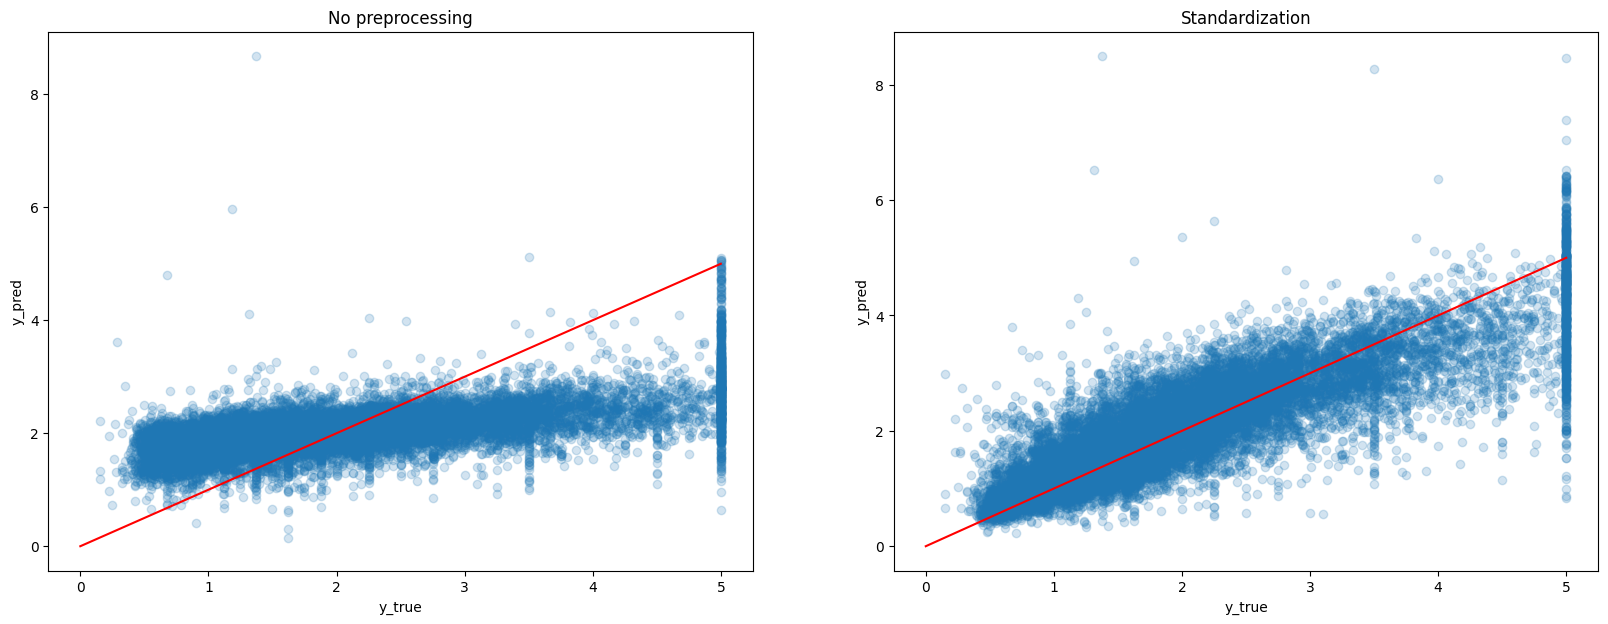

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(20,7))
model_input_title = [(sklearn_model, X_train, 'No preprocessing'), (sklearn_model_stand, X_train_stand, 'Standardization')]

for i in range(2):
  model, input, title = model_input_title[i]
  _ = axes[i].scatter(Y_train, model.predict(input), alpha=.2)
  _ = axes[i].plot(range(6),'r')
  _ = axes[i].set_xlabel('y_true')
  _ = axes[i].set_ylabel('y_pred')
  _ = axes[i].set_title(title)


In [ ]:
#@title TASK 2: print MSE and MAE. What might be the downsides of using such metrics to evaluate the performance of the algorithm?

Y_pred, Y_pred_stand = sklearn_model.predict(X_test), sklearn_model_stand.predict(X_test_stand)
mae, mae_stand = mean_absolute_error(Y_pred, Y_test), mean_absolute_error(Y_pred_stand, Y_test)
mse, mse_stand = mean_squared_error(Y_pred, Y_test), mean_squared_error(Y_pred_stand, Y_test)

print(f"Mean absolute error of predictions: {mae:.5f} (without standardization), {mae_stand:.5f} (with standardization)")
print(f"Mean squared error of predictions: {mse:.5f} (without standardization), {mse_stand:.5f} (with standardization)")

Mean absolute error of predictions: 0.75635 (without standardization), 0.43971 (with standardization)
Mean squared error of predictions: 0.93022 (without standardization), 0.37708 (with standardization)


# Deep Learning frameworks

`scikit-learn` is extremely user-friendly and recommended when getting warmed-up with ML. However, the implemented models are not flexible enough to suit tailored model implementation. In particular:

The most well-known DL frameworks are:
<ul>
<li><code>tensorflow</code> backed by Google</li>
<li><code>pytorch</code> backed by Meta</li>
<li><code>JAX</code> backed by Google</li>
</ul>


During the lab, we will mostly use `pytorch` - of course you are free to use any library of your choice for assignments and tutorials.

To get familiar with the basics of all three frameworks, we will implement a simple neural network for each of them. Our FNN will contain 3 hidden layers (of size $2^{10}, 2^7, 2^5$) and a final layer with a sigmoid activation.

# PyTorch


In [ ]:
%pip uninstall torch --y
%pip install torch==2.1.0

import torch
torch.__version__


Found existing installation: torch 2.1.0
Uninstalling torch-2.1.0:
  Successfully uninstalled torch-2.1.0
  Using cached torch-2.1.0-cp310-cp310-manylinux1_x86_64.whl.metadata (25 kB)
Using cached torch-2.1.0-cp310-cp310-manylinux1_x86_64.whl (670.2 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.4.0+cu121 requires torch==2.4.0, but you have torch 2.1.0 which is incompatible.


'2.4.0+cu121'

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
X_train_torch, X_test_torch = torch.tensor(X_train.values), torch.tensor(X_test.values) #torch only accepts torch.Tensors as input
Y_train_torch, Y_test_torch = torch.tensor(Y_train.values), torch.tensor(Y_test.values) #torch only accepts torch.Tensors as input

class MyDataset(Dataset):

  def __init__(self, X, Y):
    self.X = X.to(torch.double)
    self.Y = Y.to(torch.double)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.Y[idx]


train_dataset = MyDataset(X_train_torch, Y_train_torch)
test_dataset = MyDataset(X_test_torch, Y_test_torch)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

torch.set_default_dtype(torch.float64)

class TorchModel(nn.Sequential): #https://pytorch.org/docs/stable/generated/torch.nn.Module.html

  def __init__(self, input_size):
      super().__init__()

      self.layer1 = nn.Linear(in_features=input_size, out_features=2**10)
      self.relu1 = nn.ReLU()
      self.layer2 = nn.Linear(in_features=2**10, out_features=2**7)
      self.relu2 = nn.ReLU()
      self.layer3 = nn.Linear(in_features=2**7, out_features=2**5)
      self.relu3 = nn.ReLU()
      self.output_layer = nn.Linear(in_features=2**5, out_features=1)

def torch_train(model, data, optimizer, loss='L1Loss', batch_size=32, epochs=5, shuffle=False, verbose=False):

  criterion = getattr(nn, loss)() #nn.MSELoss()
  dataloader = DataLoader(data, batch_size=batch_size, shuffle=shuffle)
  model.train()

  for epoch in range(epochs):
    for i, (X, Y) in enumerate(dataloader):
        optimizer.zero_grad()
        # Forward pass
        pred = model(X)
        loss = criterion(pred, Y)
        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        if verbose:
          print(f"Epoch: {epoch} iter: {i} loss: {loss.item():.5f}")

  return model

torch_model = TorchModel(input_size=8)
optimizer = optim.Adam(torch_model.parameters(), lr=10**-2)
model = torch_train(torch_model, train_dataset, optimizer, epochs=1,verbose=True)


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/loss.py:101: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


Epoch: 0 iter: 0 loss: 14.31261
Epoch: 0 iter: 1 loss: 740.00987
Epoch: 0 iter: 2 loss: 155.02769
Epoch: 0 iter: 3 loss: 132.82252
Epoch: 0 iter: 4 loss: 175.55321
Epoch: 0 iter: 5 loss: 74.21640
Epoch: 0 iter: 6 loss: 89.59496
Epoch: 0 iter: 7 loss: 104.17712
Epoch: 0 iter: 8 loss: 56.85614
Epoch: 0 iter: 9 loss: 16.85221
Epoch: 0 iter: 10 loss: 61.75939
Epoch: 0 iter: 11 loss: 55.98505
Epoch: 0 iter: 12 loss: 3.40966
Epoch: 0 iter: 13 loss: 1.44867
Epoch: 0 iter: 14 loss: 1.49889
Epoch: 0 iter: 15 loss: 1.47658
Epoch: 0 iter: 16 loss: 1.36625
Epoch: 0 iter: 17 loss: 2.69228
Epoch: 0 iter: 18 loss: 1.79309
Epoch: 0 iter: 19 loss: 2.11674
Epoch: 0 iter: 20 loss: 1.97124
Epoch: 0 iter: 21 loss: 1.35350
Epoch: 0 iter: 22 loss: 1.39217
Epoch: 0 iter: 23 loss: 1.50020
Epoch: 0 iter: 24 loss: 1.58918
Epoch: 0 iter: 25 loss: 1.12849
Epoch: 0 iter: 26 loss: 1.19333
Epoch: 0 iter: 27 loss: 1.46155
Epoch: 0 iter: 28 loss: 1.35170
Epoch: 0 iter: 29 loss: 1.05783
Epoch: 0 iter: 30 loss: 1.32522
E

#Tensorflow

In [ ]:
#we can define each layer with different activation functions and initial weight matrices
import tensorflow as tf
from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.nn import relu, tanh
#https://www.tensorflow.org/api_docs/python/tf/keras/Sequential


tf.random.set_seed(GLOBAL_RANDOM_STATE)

TFModel = Sequential([Dense(2**10, input_shape=(X_train.shape[1],), activation=tanh),
                       Dense(2**7, activation=tanh),
                       Dense(2**5, activation=tanh),
                       Dense(1)]) #output layer, linear activation function

#we convert input to np.arrays as Tensorflow does not accept pd.DataFrames
X_train_np, Y_train_np, X_test_np, Y_test_np =  X_train.values, Y_train.values, X_test.values, Y_test.values

loss = 'mean_squared_error'
TFModel.compile(loss=loss)
TFModel.fit(X_train_np, Y_train_np, batch_size=32, epochs=5, shuffle=False, verbose=True)

Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


516/516 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1.4851
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.3482
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.3437
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.3427
Epoch 5/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.3419


In [ ]:
# @title Task 2: change activation function of the last layer to tanh and retrain the model
TFModel.layers[-1].activation = tanh

for i, layer in enumerate(TFModel.layers):
    try:
        print(f"Activation function for layer {i}: {layer.activation}")
    except AttributeError:
        print(f"Layer {i} uses no activation function")


TFModel.fit(X_train_np, Y_train_np, batch_size=200, epochs=5)

#JAX

In [ ]:
import jax
import jax.numpy as jnp
from jax import value_and_grad

def jax_dense_layer(x, weights, relu=False):
  '''Define a dense layer'''
  W,b = weights
  out = jnp.dot(x, W.T) + b
  if relu:
    out = jnp.maximum(jnp.zeros_like(a=out),out)
  return out

def jax_init_weights(shapes, input_shape, output_shape, seed):
  weights = []
  seed = jax.random.PRNGKey(seed if seed is not None else 42)
  for i, shape in enumerate(shapes):
      if i==0:
          w = jax.random.uniform(key=seed, shape=(shape, input_shape), minval=-1.0, maxval=1.0, dtype=jnp.float32)
      else:
          w = jax.random.uniform(key=seed, shape=(shape, shapes[i-1]), minval=-1.0, maxval=1.0, dtype=jnp.float32)
      b = jax.random.uniform(key=seed, minval=-1.0, maxval=1.0, shape=(shape,), dtype=jnp.float32)
      #append weights
      weights.append([w,b])

  w_out = jax.random.uniform(key=seed, shape=(output_shape, shape), minval=-1.0, maxval=1.0, dtype=jnp.float32)
  b_out = jax.random.uniform(key=seed, minval=-1.0, maxval=1.0, shape=(output_shape,), dtype=jnp.float32)
  weights.append([w_out,b_out])
  #print(",".join([f"w{i}:{w.shape} b{i}:{b.shape}" for i, (w,b) in enumerate(weights)]))
  return weights


def jax_forward(x, weights):
  '''simple forward pass'''
  depth = len(weights)
  for i in range(depth):
    if i <= depth -1:
      x = jax_dense_layer(x, weights=weights[i], relu=True)
    else:
      x = jax_dense_layer(x, weights=weights[depth], relu=False)

  return x


def jax_mse_loss(x, y, weights):
  '''MSE loss function'''
  pred = jax_forward(x, weights)
  loss = jnp.mean((pred - y) ** 2)
  return loss


def grad_update(x, y, weights):
  '''return value and gradient update of the loss function wrt the weights'''
  return value_and_grad(jax_mse_loss)(x, y, weights)


def weights_update(weights, grads, lr=0.01):
    '''update weights for layers of NN'''
    depth = len(weights)
    for j in range(len(weights)):
        weights[j][0] -= lr * grads[j][0] ## updates w
        weights[j][1] -= lr * grads[j][1] ## updates b

    return weights

def train_step(x, y, weights, lr=0.01):
    '''single epoch training step'''
    loss, grads = grad_update(x, y, weights)
    weights = weights_update(weights, grads, lr=lr) ## updates w,b
    return loss, weights


def jax_train(layers_shape, torch_dataset, batch_size=32, epochs=5, shuffle=False, verbose=False, seed=None):
  '''initializes the FNN model, loops over data and updates weights'''

  dataloader = DataLoader(torch_dataset, batch_size=batch_size, shuffle=shuffle)

  #for epoch in tqdm(range(EPOCHS)):
  for epoch in range(epochs):
    for i, (X, Y) in enumerate(dataloader):
      X = jnp.array(X.numpy())
      Y = jnp.array(Y.numpy())[:, None]

      if epoch == 0 and i == 0:
        input_shape = X.shape[-1]
        output_shape = Y.shape[-1]
        weights = jax_init_weights(layers_shape, input_shape, output_shape, seed=seed)

      loss, weights = train_step(X,Y, weights)
      if verbose:
        print("MSE : {:.2f} at epoch {}, iter {}".format(jnp.array(loss).mean(),epoch, i))

  return weights




jax_train([2**10, 2**7, 2**5], train_dataset, epochs=1, verbose=True)

MSE : 6077875200.00 at epoch 0, iter 0
MSE : 5.83 at epoch 0, iter 1
MSE : 9.78 at epoch 0, iter 2
MSE : 5.46 at epoch 0, iter 3
MSE : 6.91 at epoch 0, iter 4
MSE : 7.00 at epoch 0, iter 5
MSE : 5.55 at epoch 0, iter 6
MSE : 5.34 at epoch 0, iter 7
MSE : 6.54 at epoch 0, iter 8
MSE : 5.27 at epoch 0, iter 9
MSE : 7.33 at epoch 0, iter 10
MSE : 5.72 at epoch 0, iter 11
MSE : 4.11 at epoch 0, iter 12
MSE : 6.63 at epoch 0, iter 13
MSE : 5.79 at epoch 0, iter 14
MSE : 6.28 at epoch 0, iter 15
MSE : 4.11 at epoch 0, iter 16
MSE : 4.92 at epoch 0, iter 17
MSE : 4.66 at epoch 0, iter 18
MSE : 5.61 at epoch 0, iter 19
MSE : 6.51 at epoch 0, iter 20
MSE : 4.44 at epoch 0, iter 21
MSE : 5.96 at epoch 0, iter 22
MSE : 5.35 at epoch 0, iter 23
MSE : 5.54 at epoch 0, iter 24
MSE : 5.62 at epoch 0, iter 25
MSE : 5.72 at epoch 0, iter 26
MSE : 7.28 at epoch 0, iter 27
MSE : 7.05 at epoch 0, iter 28
MSE : 4.63 at epoch 0, iter 29
MSE : 4.71 at epoch 0, iter 30
MSE : 6.46 at epoch 0, iter 31
MSE : 6.2

[[Array([[-752.3164 , -752.18896, -753.69794, ..., -752.98016, -752.0154 ,
          -751.98975],
         [-752.7056 , -753.86145, -752.97595, ..., -752.3301 , -753.6689 ,
          -752.91   ],
         [-753.78143, -753.34503, -753.7586 , ..., -753.2991 , -753.3373 ,
          -752.2572 ],
         ...,
         [-753.4451 , -753.7627 , -753.4973 , ..., -753.31323, -751.90405,
          -752.7842 ],
         [-752.9898 , -753.6814 , -753.6987 , ..., -752.6081 , -753.8403 ,
          -753.4674 ],
         [-753.4898 , -753.5986 , -753.3912 , ..., -752.77814, -751.915  ,
          -752.6444 ]], dtype=float32),
  Array([-2032.2974, -2031.402 , -2032.9834, ..., -2033.2601, -2032.457 ,
         -2032.4297], dtype=float32)],
 [Array([[-1984.2922, -1983.9015, -1984.2002, ..., -1985.012 , -1983.4012,
          -1983.7739],
         [-1985.1217, -1984.9031, -1984.3326, ..., -1983.8496, -1984.3346,
          -1984.1064],
         [-1983.7195, -1984.6968, -1984.7836, ..., -1983.5876, -1983.567